In [1]:
from dg2cd.losses import *
import torch

In [2]:
# Lets test the function with some dummy data
if __name__ == "__main__":
    # Create dummy features and labels
    features = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0], [7.0, 8.0]])
    labels = torch.tensor([0, 1, 0, 1])
    num_classes = 3

    # Compute class prototypes
    prototypes, present = class_prototypes(features, labels, num_classes)

    print("Prototypes:\n", prototypes)
    print("Present classes:\n", present)

Prototypes:
 tensor([[3., 4.],
        [5., 6.],
        [0., 0.]])
Present classes:
 tensor([ True,  True, False])


In [3]:
import torch

features = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [0.0, 1.0],
])

labels = torch.tensor([0, 1, 0, 1])

loss_internal = supervised_prototype_contrastive_loss(
    features=features,
    labels=labels,
    num_classes=2,
    temperature=1.0,
    reduction="mean",
)

prototypes = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
])

loss_external = supervised_prototype_contrastive_loss(
    features=features,
    labels=labels,
    prototypes=prototypes,
    temperature=1.0,
    reduction="mean",
)

expected = torch.tensor(0.3132617)

print("Internal:", loss_internal.item())
print("External:", loss_external.item())
print("Expected:", expected.item())

assert torch.allclose(loss_internal, expected, atol=1e-6)
assert torch.allclose(loss_external, expected, atol=1e-6)
assert torch.allclose(loss_internal, loss_external, atol=1e-6)

print("All tests passed")

Internal: 0.31326165795326233
External: 0.31326165795326233
Expected: 0.3132616877555847
All tests passed


In [2]:
import torch
from dg2cd.losses import unsupervised_contrastive_loss

torch.manual_seed(0)
B, D = 8, 16

# 1. Views identical -> positive similarity is maximal -> loss near its floor.
z = torch.randn(B, D)
print("identical views:", unsupervised_contrastive_loss(z, z).item())

# 2. Views unrelated -> no usable signal -> loss approaches log(2B-1).
import math
z1, z2 = torch.randn(B, D), torch.randn(B, D)
print("random views:   ", unsupervised_contrastive_loss(z1, z2).item())
print("log(2B-1) =     ", math.log(2 * B - 1))

# 3. Gradients reach the encoder.
z1 = torch.randn(B, D, requires_grad=True)
unsupervised_contrastive_loss(z1, torch.randn(B, D)).backward()
print("grad finite:", torch.isfinite(z1.grad).all().item(), "| nonzero:", (z1.grad.abs().sum() > 0).item())

identical views: 0.0005668401718139648
random views:    13.967005729675293
log(2B-1) =      2.70805020110221
grad finite: True | nonzero: True


In [1]:
import math
import torch
from dg2cd.losses import open_set_adversarial_loss
from dg2cd.models import grad_reverse

# --- Eq. 8: minimum sits exactly at p(unknown) = alpha = 0.5 ---
def loss_at(p_unknown):
    # two known classes sharing (1 - p) equally, plus the unknown class
    p = torch.tensor([[(1 - p_unknown) / 2, (1 - p_unknown) / 2, p_unknown]])
    return open_set_adversarial_loss(torch.log(p)).item()   # log-probs are valid logits

for p in [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    print(f"p(unknown)={p:>4}  L_adv={loss_at(p):.4f}")
print("expected minimum log(2) =", math.log(2))

# --- no NaN even at the extremes the encoder is pushing toward ---
extreme = torch.tensor([[-60.0, -60.0, 60.0]])          # p(unknown) = 1.0 in float32
print("extreme logits ->", open_set_adversarial_loss(extreme).item(), "(finite, no NaN)")

# --- GRL: forward identity, backward negated ---
x = torch.randn(4, 3, requires_grad=True)
grad_reverse(x, 1.0).sum().backward()
print("GRL grad (expect all -1):", x.grad.unique().tolist())

x = torch.randn(4, 3, requires_grad=True)
(x * 1.0).sum().backward()
print("plain grad (expect all +1):", x.grad.unique().tolist())

p(unknown)=0.01  L_adv=2.3076
p(unknown)= 0.1  L_adv=1.2040
p(unknown)= 0.3  L_adv=0.7803
p(unknown)= 0.5  L_adv=0.6931
p(unknown)= 0.7  L_adv=0.7803
p(unknown)= 0.9  L_adv=1.2040
p(unknown)=0.99  L_adv=2.3076
expected minimum log(2) = 0.6931471805599453
extreme logits -> 59.65342712402344 (finite, no NaN)
GRL grad (expect all -1): [-1.0]
plain grad (expect all +1): [1.0]


In [1]:
import torch
from dg2cd.losses import confidence_margin_loss

def loss_for(probs):
    """probs: last entry is the unknown class."""
    p = torch.tensor([probs])
    return confidence_margin_loss(torch.log(p)).item()

cases = {
    "confident known   [0.90, 0.05 | 0.05]": [0.90, 0.05, 0.05],
    "confident novel   [0.05, 0.05 | 0.90]": [0.05, 0.05, 0.90],
    "exactly at margin [0.85, 0.00 | 0.15]": [0.85, 0.001, 0.149],
    "mildly unsure     [0.50, 0.10 | 0.40]": [0.50, 0.10, 0.40],
    "fully uniform     [0.33, 0.33 | 0.33]": [1/3, 1/3, 1/3],
}
for name, p in cases.items():
    print(f"{name}  ->  L_margin = {loss_for(p):.4f}")

# Symmetry: confident-known and confident-novel must cost the same.
print("\nsymmetric:", loss_for([0.9, 0.05, 0.05]) == loss_for([0.05, 0.05, 0.9]))

# Hinge: samples past the margin get zero gradient and cannot be pushed further.
x = torch.log(torch.tensor([[0.90, 0.05, 0.05]])).requires_grad_(True)
confidence_margin_loss(x).backward()
print("grad when satisfied (expect all 0):", x.grad.abs().sum().item())

y = torch.log(torch.tensor([[1/3, 1/3, 1/3]])).requires_grad_(True)
confidence_margin_loss(y).backward()
print("grad when ambiguous (expect > 0):  ", y.grad.abs().sum().item())

confident known   [0.90, 0.05 | 0.05]  ->  L_margin = 0.0000
confident novel   [0.05, 0.05 | 0.90]  ->  L_margin = 0.0000
exactly at margin [0.85, 0.00 | 0.15]  ->  L_margin = 0.0000
mildly unsure     [0.50, 0.10 | 0.40]  ->  L_margin = 0.6000
fully uniform     [0.33, 0.33 | 0.33]  ->  L_margin = 0.7000

symmetric: True
grad when satisfied (expect all 0): 0.0
grad when ambiguous (expect > 0):   0.0


In [2]:
from dg2cd.utils import load_config

cfg = load_config("configs/pacs.yaml")

print("source domain :", cfg.dataset.source)
print("known classes :", cfg.dataset.known_classes)
print("novel classes :", [c for c in cfg.dataset.class_names
                          if c not in cfg.dataset.known_classes])
print("episodes      :", cfg.episodic.n_global, "x", cfg.episodic.n_episodes)
print("margin m      :", cfg.losses.margin_m)
print("lambda_da     :", cfg.losses.lambda_da)
print("ip2p steps    :", cfg.synthetic.instructpix2pix.num_inference_steps)

# round-trip check
import yaml
assert yaml.safe_load(yaml.safe_dump(cfg.to_dict())) == cfg.to_dict()
print("\nto_dict round-trips cleanly")

source domain : photo
known classes : ['dog', 'elephant', 'girraffe', 'guitar']
novel classes : ['elepahant', 'giraffe', 'horse', 'house', 'person']
episodes      : 10 x 6
margin m      : 0.7
lambda_da     : 0.2
ip2p steps    : 10

to_dict round-trips cleanly


In [1]:
import torch
from dg2cd.models import DINOViTBackbone
from dg2cd.utils import load_config

cfg = load_config("configs/pacs.yaml")
model = DINOViTBackbone.from_config(cfg.backbone)     # downloads ~330 MB once

trainable, total = model.parameter_counts()
print(f"trainable : {trainable:,}")
print(f"total     : {total:,}")
print(f"percent   : {100 * trainable / total:.3f}%")
print("\npaper Table 17: 7,088 K trainable / 85,799 K total / 8.261%")

print("\ntrainable block indices:", model.trainable_block_indices)
print("embed dim              :", model.embed_dim)
print("data config            :", model.data_config())

# Forward pass shape
x = torch.randn(4, 3, 224, 224)
with torch.no_grad():
    z = model(x) # Forward pass
print("\noutput shape:", tuple(z.shape), "(expect (4, 768))")

# Gradients must reach ONLY the last block.
model.train()
model(torch.randn(2, 3, 224, 224)).sum().backward() # Backward pass
got_grad = sorted({n.split(".")[2] for n, p in model.named_parameters()
                   if p.grad is not None and "blocks." in n})
print("blocks receiving gradient:", got_grad, "(expect ['11'])")

C:\Users\Borhan\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Borhan\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Borhan\.cache\huggingface\hub\models--timm--vit_base_patch16_224.dino. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrato

trainable : 7,087,872
total     : 85,798,656
percent   : 8.261%

paper Table 17: 7,088 K trainable / 85,799 K total / 8.261%

trainable block indices: [11]
embed dim              : 768
data config            : {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.9, 'crop_mode': 'center'}

output shape: (4, 768) (expect (4, 768))
blocks receiving gradient: ['11'] (expect ['11'])


In [1]:
import torch
import torch.nn.functional as F
from dg2cd.models import DINOViTBackbone, EpisodeClassifier
from dg2cd.losses import open_set_adversarial_loss, confidence_margin_loss

torch.manual_seed(0)
K = 3                                   # |Y_s^eg| for this pretend episode
clf = EpisodeClassifier(in_features=768, num_known_classes=K)
print(clf)
print("outputs:", clf.num_outputs, "| unknown index:", clf.unknown_index)

feat = torch.randn(8, 768)
print("logits shape:", tuple(clf(feat).shape), "(expect (8, 4))")

# --- the GRL flips the gradient reaching the ENCODER, not the classifier ---
f1 = torch.randn(8, 768, requires_grad=True)
f2 = f1.detach().clone().requires_grad_(True)

clf.zero_grad(); clf(f1).sum().backward()                       # no reversal
clf.zero_grad(); clf(f2, reverse_gradient=True).sum().backward()  # reversed

print("\nGRL negates the encoder-side gradient:",
      torch.allclose(f1.grad, -f2.grad))

# --- all three losses accept its output ---
y = torch.randint(0, K, (8,))
print("\nL_s     :", F.cross_entropy(clf(feat), y).item())
print("L_adv   :", open_set_adversarial_loss(clf(feat, reverse_gradient=True)).item())
print("L_margin:", confidence_margin_loss(clf(feat)).item())

# --- end to end from a real image tensor ---
enc = DINOViTBackbone(pretrained=False)     # skip the download for this check
z = enc(torch.randn(2, 3, 224, 224))
print("\nencoder -> classifier:", tuple(clf(z).shape), "(expect (2, 4))")

# --- wrong-shape input is caught, not silently broadcast ---
try:
    clf(torch.randn(2, 197, 768))
except ValueError as e:
    print("\nrejected bad shape:", e)

C:\Users\Borhan\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EpisodeClassifier(
  in_features=768, known=3, outputs=4
  (net): Linear(in_features=768, out_features=4, bias=True)
)
outputs: 4 | unknown index: 3
logits shape: (8, 4) (expect (8, 4))

GRL negates the encoder-side gradient: True

L_s     : 1.7754908800125122
L_adv   : 0.8459638357162476
L_margin: 0.5247046947479248

encoder -> classifier: (2, 4) (expect (2, 4))

rejected bad shape: expected (B, 768) features, got (2, 197, 768)


known: ['dog', 'elephant', 'giraffe', 'guitar']
novel: ['horse', 'house', 'person']
art_painting   2048
cartoon        2344
photo          1670
sketch         3929
TOTAL          9991   (paper: 9991)

source (known only): 759 images
per class: {'dog': 189, 'elephant': 202, 'giraffe': 182, 'guitar': 186}
label range: 0 - 3 (expect 0 - 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].



view1: (3, 224, 224) | view2: (3, 224, 224) | label: 0
views differ (augmentation is live): True
normalised range: -2.08 to 2.64


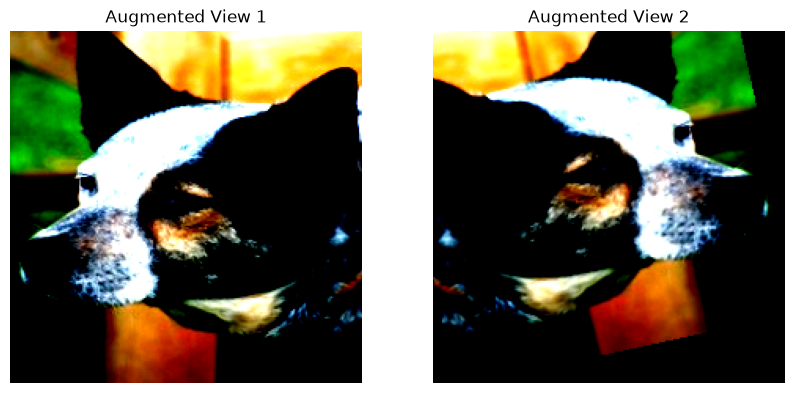


target (all classes): 2344 images, labels 0 - 6
old-class mask sum: 1327


In [11]:
from dg2cd.utils import load_config
from dg2cd.models import DINOViTBackbone
from dg2cd.data import PACSDataset, build_transforms, known_novel_split
import random
from matplotlib import pyplot as plt


cfg = load_config("configs/pacs.yaml")
known, novel = known_novel_split(cfg.dataset)
print("known:", known)
print("novel:", novel)

# --- dataset sizes must match the paper: 2048 / 2344 / 1670 / 3929 = 9991 ---
total = 0
for domain in cfg.dataset.domains:
    ds = PACSDataset(cfg.dataset.root, domain, cfg.dataset.class_names)
    total += len(ds)
    print(f"{domain:<13} {len(ds):>5}")
print(f"{'TOTAL':<13} {total:>5}   (paper: 9991)")

# --- source domain restricted to known classes ---
src = PACSDataset(cfg.dataset.root, cfg.dataset.source, known)
print("\nsource (known only):", len(src), "images")
print("per class:", src.class_counts())
print("label range:", src.labels_tensor().min().item(),
      "-", src.labels_tensor().max().item(), "(expect 0 - 3)")

# --- transforms, wired to the backbone's expectations ---
backbone = DINOViTBackbone(pretrained=True)
train_tf, eval_tf = build_transforms(backbone.data_config(), cfg.augmentation)

src_train = PACSDataset(cfg.dataset.root, cfg.dataset.source, known, transform=train_tf)
index = random.randint(0, len(src_train) - 1)
(v1, v2), label = src_train[index]
print("\nview1:", tuple(v1.shape), "| view2:", tuple(v2.shape), "| label:", label)
print("views differ (augmentation is live):", not v1.allclose(v2))
print("normalised range:", round(v1.min().item(), 2), "to", round(v1.max().item(), 2))

augmented_view_1, augmented_view_2 = v1.permute(1, 2, 0).numpy(), v2.permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(augmented_view_1)
plt.title("Augmented View 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented_view_2)
plt.title("Augmented View 2")
plt.axis("off")

plt.show()

# --- target domain keeps all 7 classes ---
tgt = PACSDataset(cfg.dataset.root, "cartoon", cfg.dataset.class_names, transform=eval_tf)
print("\ntarget (all classes):", len(tgt), "images, labels 0 -", 
      tgt.labels_tensor().max().item())
print("old-class mask sum:", (tgt.labels_tensor() < len(known)).sum().item())